# 06 — Model Evaluation

## Smart India Real Estate Analytics

### Objective

The objective of this notebook is to perform the final evaluation of the selected property price prediction model.

The tuned HistGradientBoosting model selected during model training will be evaluated using the held-out test dataset.

The evaluation will include:

- Final regression metrics
- Actual vs predicted price analysis
- Residual/error analysis
- Prediction error distribution
- Model performance visualization
- Interpretation of model strengths and limitations

The test dataset will not be used for further model training or hyperparameter tuning.

## Evaluation Strategy

The final selected model was determined during `05_model_training.ipynb`.

The following artifacts will be loaded:

- `final_model.joblib` — selected trained model
- `preprocessor.joblib` — preprocessing transformer
- `X_test_processed.npz` — processed test features
- `y_test.csv` — test target values

The evaluation will be performed on the untouched test dataset to estimate how the model generalizes to unseen properties.

In [1]:
import numpy as np
import pandas as pd
import joblib

from pathlib import Path
from scipy import sparse

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt


MODEL_DIR = Path("../models")

print("Evaluation environment initialized.")

Evaluation environment initialized.


In [2]:
FINAL_MODEL_PATH = MODEL_DIR / "final_model.joblib"
PREPROCESSOR_PATH = MODEL_DIR / "preprocessor.joblib"

TEST_FEATURES_PATH = MODEL_DIR / "X_test_processed.npz"
TEST_TARGET_PATH = MODEL_DIR / "y_test.csv"

final_model = joblib.load(FINAL_MODEL_PATH)
preprocessor = joblib.load(PREPROCESSOR_PATH)

X_test_processed = sparse.load_npz(TEST_FEATURES_PATH)

y_test = pd.read_csv(
    TEST_TARGET_PATH
)["Price"]

print("Final model loaded successfully.")
print("Preprocessor loaded successfully.")
print("Test features loaded successfully.")
print("Test target loaded successfully.")

print("\nTest features shape:", X_test_processed.shape)
print("Test target shape:", y_test.shape)

Final model loaded successfully.
Preprocessor loaded successfully.
Test features loaded successfully.
Test target loaded successfully.

Test features shape: (2905, 1738)
Test target shape: (2905,)


## Final Test Predictions

The saved final model will generate predictions for the held-out test dataset.

The test features were processed using the same preprocessing pipeline established during model development.

No model fitting or parameter tuning is performed in this notebook.

In [3]:
# Convert sparse test matrix to dense format required by HistGradientBoosting
X_test_final = X_test_processed.toarray().astype(np.float32)

print("Final test matrix shape:", X_test_final.shape)

final_predictions = final_model.predict(
    X_test_final
)

print("Final predictions generated successfully.")
print("Number of predictions:", len(final_predictions))

Final test matrix shape: (2905, 1738)
Final predictions generated successfully.
Number of predictions: 2905


## Final Model Performance

The final model is evaluated on the untouched test dataset using MAE, RMSE, and R².

These metrics provide the final quantitative assessment of the selected model's predictive performance on unseen properties.

In [4]:
final_mae = mean_absolute_error(
    y_test,
    final_predictions
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_predictions
    )
)

final_r2 = r2_score(
    y_test,
    final_predictions
)

final_metrics = {
    "MAE": final_mae,
    "RMSE": final_rmse,
    "R2": final_r2
}

print(f"Final MAE:  ₹{final_mae:,.2f}")
print(f"Final RMSE: ₹{final_rmse:,.2f}")
print(f"Final R²:   {final_r2:.4f}")

Final MAE:  ₹5,181,651.46
Final RMSE: ₹19,559,862.63
Final R²:   0.2175


## Actual vs Predicted Prices

An Actual vs Predicted scatter plot is used to visually assess prediction performance.

A perfectly accurate model would place all observations along the diagonal line:

`Predicted Price = Actual Price`

Points far from the diagonal represent larger prediction errors.

This visualization also helps identify whether the model systematically underpredicts or overpredicts particular price ranges.

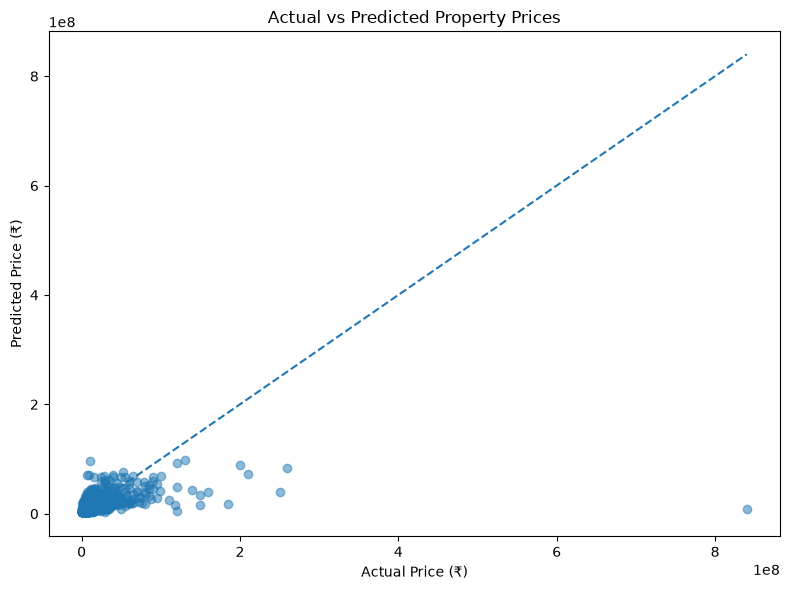

In [5]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    final_predictions,
    alpha=0.5
)

min_price = min(y_test.min(), final_predictions.min())
max_price = max(y_test.max(), final_predictions.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Price (₹)")
plt.ylabel("Predicted Price (₹)")
plt.title("Actual vs Predicted Property Prices")

plt.tight_layout()
plt.show()

## Log-Scale Actual vs Predicted Prices

Because property prices span a very wide range, a logarithmic scale is used to provide a clearer view of prediction performance across both lower- and higher-priced properties.

The logarithmic visualization does not change the model or evaluation metrics. It is used only to improve visual interpretation.

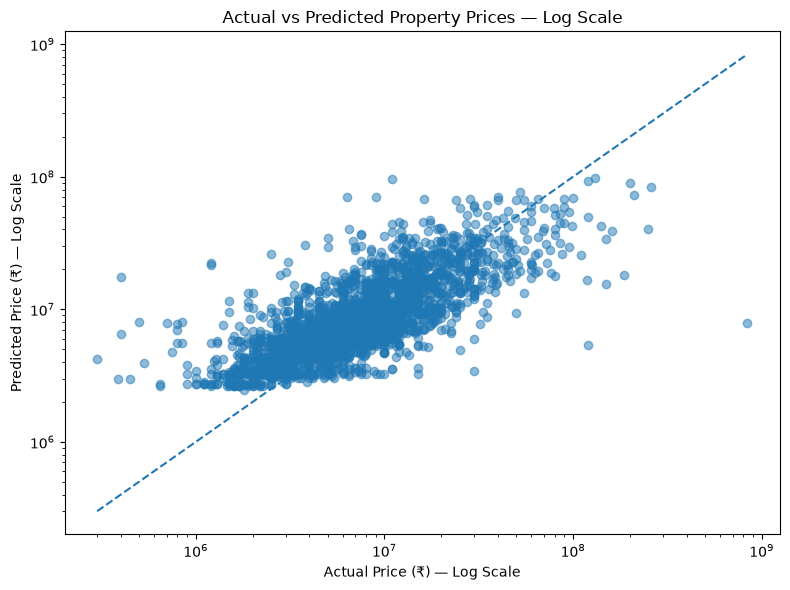

In [6]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    final_predictions,
    alpha=0.5
)

positive_min = min(
    y_test[y_test > 0].min(),
    final_predictions[final_predictions > 0].min()
)

positive_max = max(
    y_test.max(),
    final_predictions.max()
)

plt.plot(
    [positive_min, positive_max],
    [positive_min, positive_max],
    linestyle="--"
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Actual Price (₹) — Log Scale")
plt.ylabel("Predicted Price (₹) — Log Scale")
plt.title("Actual vs Predicted Property Prices — Log Scale")

plt.tight_layout()
plt.show()

In [7]:
residuals = y_test.to_numpy() - final_predictions

print("Residual mean:", residuals.mean())
print("Residual median:", np.median(residuals))
print("Residual standard deviation:", residuals.std())

Residual mean: 284784.6516317314
Residual median: -1005683.2623102628
Residual standard deviation: 19557789.340991814


## Residual Distribution

The residual distribution is visualized to examine the spread and direction of prediction errors.

A residual of zero represents a perfectly accurate prediction.

The shape of the distribution helps identify:

- overall prediction bias
- spread of errors
- extreme residuals
- asymmetry caused by large prediction errors

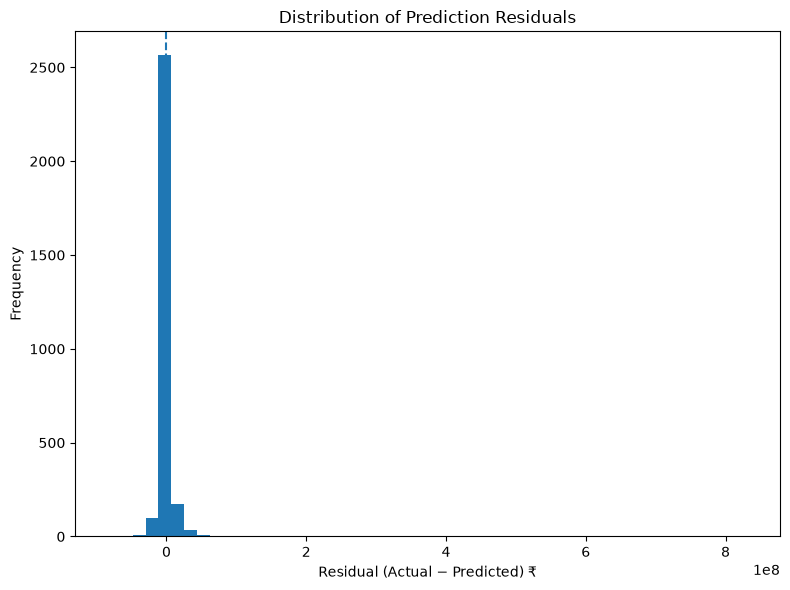

In [8]:
plt.figure(figsize=(8, 6))

plt.hist(
    residuals,
    bins=50
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Residual (Actual − Predicted) ₹")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Residuals")

plt.tight_layout()
plt.show()

## Residuals vs Predicted Price

A residuals-vs-predicted plot is used to examine whether prediction errors change systematically with the predicted property price.

A well-behaved regression model should ideally show residuals scattered around zero without a strong systematic pattern.

Increasing residual spread at higher predicted prices would indicate that prediction uncertainty grows for expensive properties.

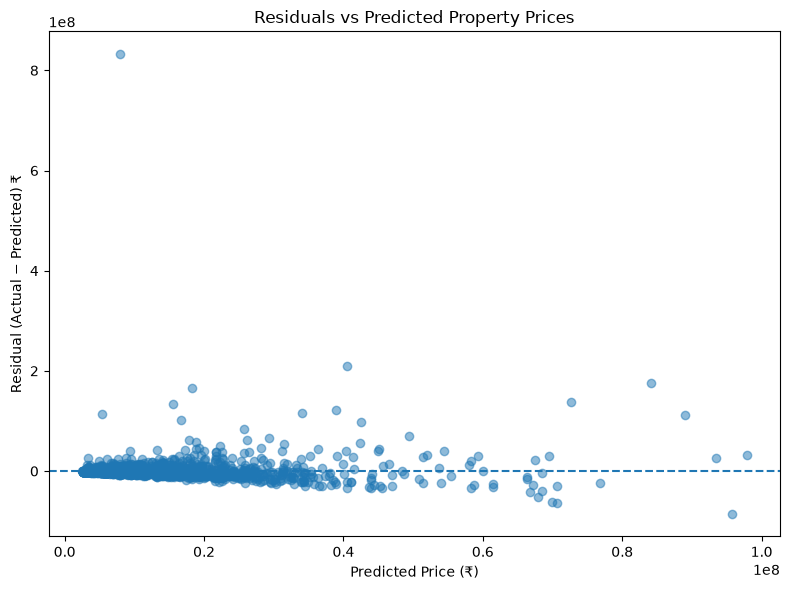

In [9]:
plt.figure(figsize=(8, 6))

plt.scatter(
    final_predictions,
    residuals,
    alpha=0.5
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Price (₹)")
plt.ylabel("Residual (Actual − Predicted) ₹")
plt.title("Residuals vs Predicted Property Prices")

plt.tight_layout()
plt.show()

## Underprediction and Overprediction Analysis

Residual signs are used to determine the proportion of test observations that were underpredicted and overpredicted.

- Positive residual: actual price is greater than predicted price.
- Negative residual: actual price is lower than predicted price.
- Residual near zero: prediction is close to the actual value.

In [10]:
underpredictions = np.sum(residuals > 0)
overpredictions = np.sum(residuals < 0)
exact_predictions = np.sum(residuals == 0)

total_predictions = len(residuals)

print(f"Underpredictions: {underpredictions}")
print(f"Overpredictions: {overpredictions}")
print(f"Exact predictions: {exact_predictions}")

print(f"\nUnderprediction percentage: "
      f"{underpredictions / total_predictions * 100:.2f}%")

print(f"Overprediction percentage: "
      f"{overpredictions / total_predictions * 100:.2f}%")

Underpredictions: 998
Overpredictions: 1907
Exact predictions: 0

Underprediction percentage: 34.35%
Overprediction percentage: 65.65%


## Residual Bias Findings

The residual sign analysis shows that 65.65% of test properties were overpredicted, while 34.35% were underpredicted.

Although overprediction occurs more frequently, the underpredictions include several very large positive residuals. Therefore, prediction frequency alone does not determine overall error magnitude.

Combined with the residual distribution and residual-vs-predicted analysis, the results indicate that the model has non-constant prediction error and struggles particularly with some high-value properties.

## Final Model Evaluation Summary

### Final Model

**Tuned HistGradientBoosting Regressor**

### Test Performance

| Metric | Result |
|---|---:|
| MAE | ₹51.82 lakh |
| RMSE | ₹1.96 crore |
| R² | 0.2175 |

### Key Evaluation Findings

- The model achieves an R² of approximately 0.218 on the unseen test dataset.
- Average absolute prediction error is approximately ₹51.82 lakh.
- RMSE is substantially higher than MAE because several properties produce very large prediction errors.
- Prediction error increases substantially for higher-priced properties.
- The residual distribution has a long positive tail caused by severe underprediction of some high-value properties.
- Residual analysis indicates non-constant error variance.
- The model overpredicts 65.65% of test properties and underpredicts 34.35%.
- Although overprediction occurs more frequently, some underpredictions are much larger in magnitude.
- The model therefore performs better for typical properties than for extreme high-value properties.

### Overall Assessment

The selected model provides a reproducible baseline for property price prediction using the available features. However, its relatively low R² and large errors for some high-value properties indicate that the current feature set does not capture all factors influencing property prices.

The model should therefore be presented as a predictive baseline with identified limitations rather than as a highly accurate valuation system.

In [11]:
final_metrics_table = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [
        final_mae,
        final_rmse,
        final_r2
    ]
})

final_metrics_table

,Metric,Value
0,MAE,5.181651e+06
1,RMSE,1.955986e+07
2,R²,2.175229e-01


In [12]:
final_metrics_display = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [
        f"₹{final_mae:,.2f}",
        f"₹{final_rmse:,.2f}",
        f"{final_r2:.4f}"
    ]
})

final_metrics_display

,Metric,Value
0,MAE,"₹5,181,651.46"
1,RMSE,"₹19,559,862.63"
2,R²,0.2175
